### Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Display helper
def show_image(title, img, cmap='gray'):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

### Load Image

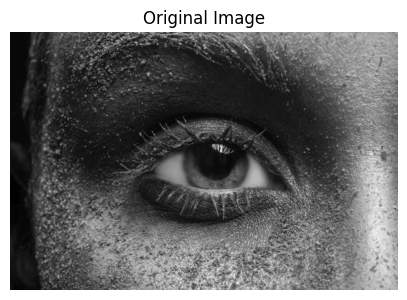

In [ ]:
# Load image in grayscale
img = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
show_image("Original Image", img)

### Experiment #1: Spatial Filtering using Convolution

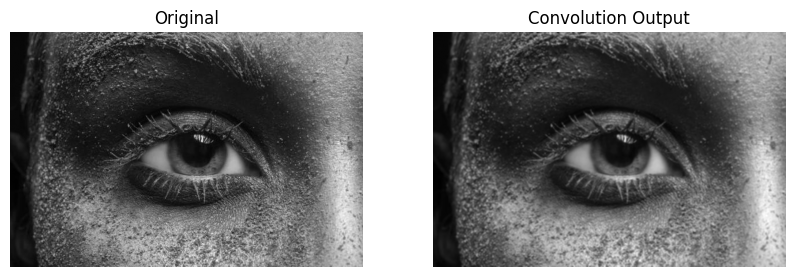

In [ ]:
kernel = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]]) / 9

# Apply convolution
kernel_flipped = np.flip(kernel)
conv_img = cv2.filter2D(img, -1, kernel_flipped)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
show_image("Original", img)

plt.subplot(1,2,2)
show_image("Convolution Output", conv_img)

- Convolution involves flipping the kernel and sliding it across the image.

### Experiment #2: Spatial Filtering using Correlation

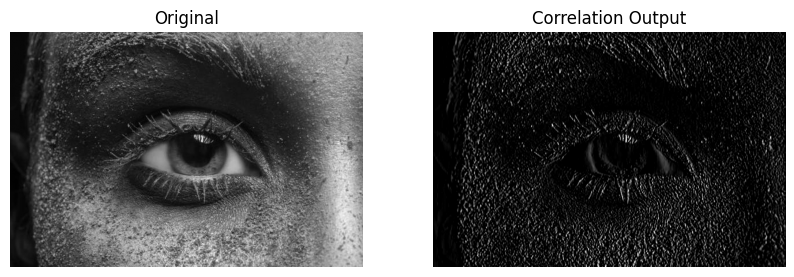

In [ ]:
# Define a different kernel (edge detection)
kernel_corr = np.array([[1, 0, -1],
                        [1, 0, -1],
                        [1, 0, -1]])

corr_img = cv2.filter2D(img, -1, kernel_corr)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
show_image("Original", img)

plt.subplot(1,2,2)
show_image("Correlation Output", corr_img)

- OpenCV's filter2D actually performs correlation by default.

### Experiment #3: Verification of Central Limit Theorem

Text(0, 0.5, 'Frequency')

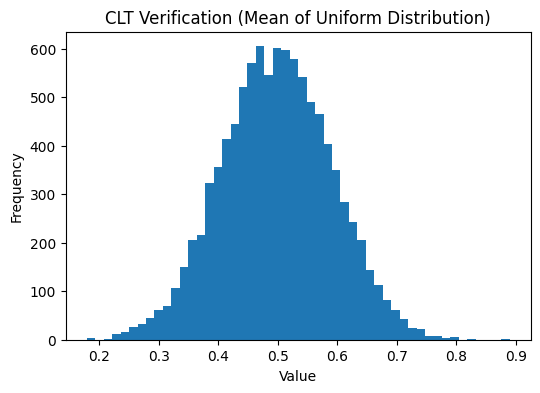

In [ ]:
# Generate random samples
samples = []

for _ in range(10000):
    vals = np.random.uniform(0, 1, 10)  # uniform distribution
    samples.append(np.mean(vals))       # take mean

samples = np.array(samples)

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(samples, bins=50)
plt.title("CLT Verification (Mean of Uniform Distribution)")
plt.xlabel("Value")
plt.ylabel("Frequency")

Central Limit Theorem states that the sum of independent random variables
tends toward a normal distribution, regardless of the original distribution.

### Filters

In [18]:
# Box filter generator
def box_kernel(size):
    return np.ones((size, size)) / (size * size)

# Gaussian kernel generator
def gaussian_kernel(size, sigma=1):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    return kernel / np.sum(kernel)

In [19]:
def apply_filters(img, kernel):
    # Correlation
    corr = cv2.filter2D(img, -1, kernel)

    # Convolution (flip kernel)
    flipped = np.flip(kernel)
    conv = cv2.filter2D(img, -1, flipped)

    return corr, conv

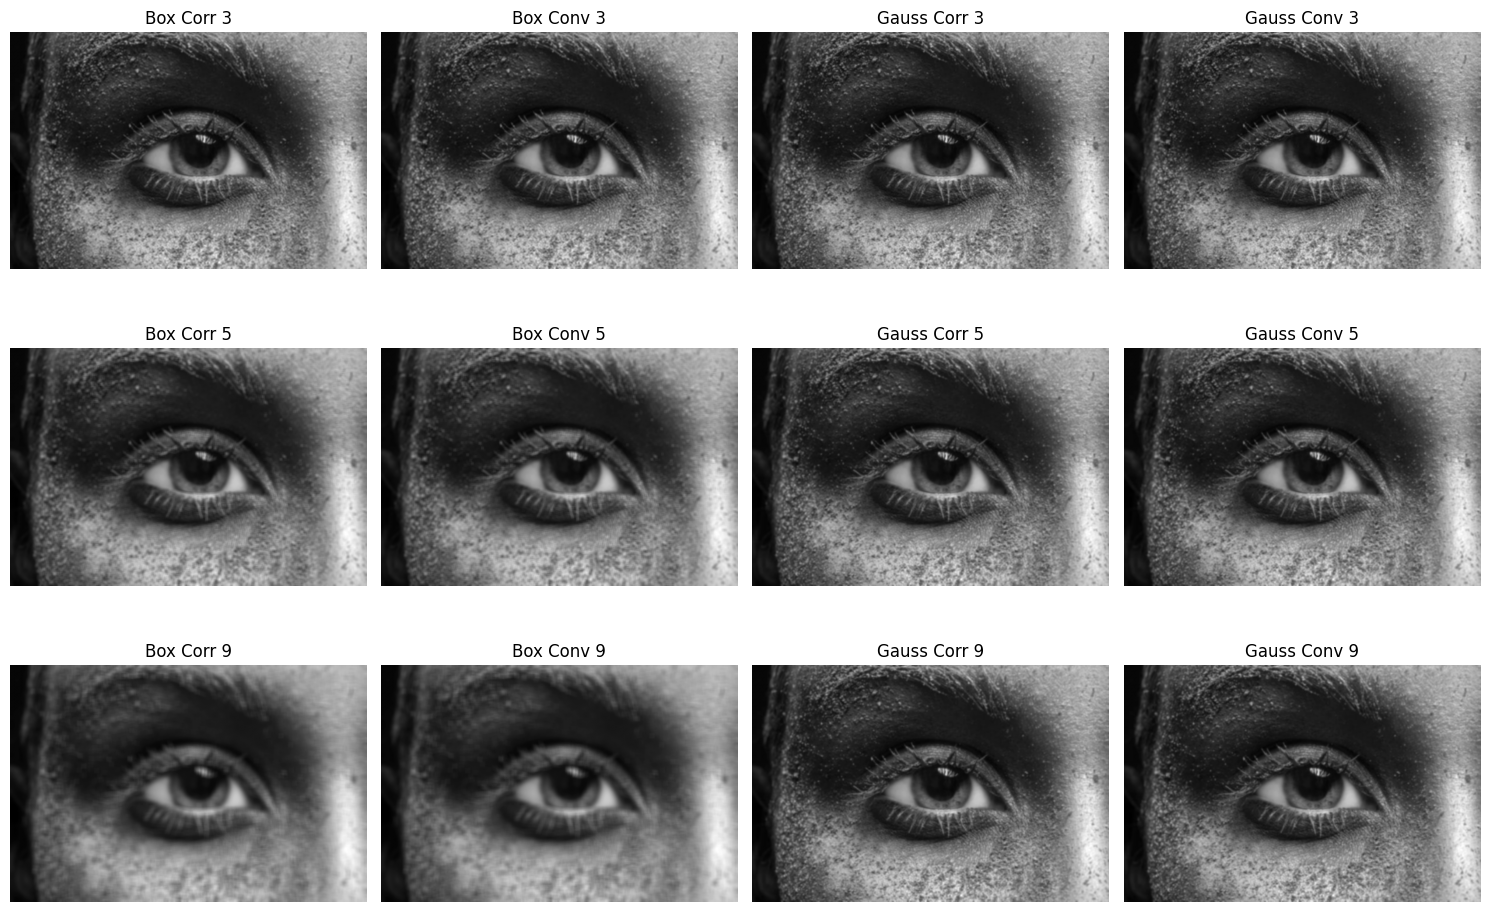

In [20]:
sizes = [3,5,9]

plt.figure(figsize=(15,10))
plot_index = 1

for size in sizes:
    box = box_kernel(size)
    gauss = gaussian_kernel(size)

    corr_box, conv_box = apply_filters(img, box)
    corr_gauss, conv_gauss = apply_filters(img, gauss)

    for title, image in [
        (f"Box Corr {size}", corr_box),
        (f"Box Conv {size}", conv_box),
        (f"Gauss Corr {size}", corr_gauss),
        (f"Gauss Conv {size}", conv_gauss)
    ]:
        plt.subplot(len(sizes), 4, plot_index)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
        plot_index += 1

plt.tight_layout()

### Assymetric Kernel Test

Text(0.5, 1.0, 'Sobel Convolution')

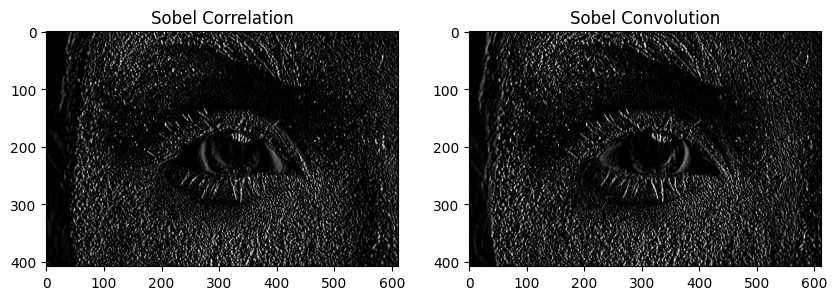

In [ ]:
sobel = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
corr_sobel, conv_sobel = apply_filters(img, sobel)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(corr_sobel, cmap='gray')
plt.title("Sobel Correlation")

plt.subplot(1,2,2)
plt.imshow(conv_sobel, cmap='gray')
plt.title("Sobel Convolution")